<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/hp_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import math
import statistics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import statsmodels.api as sm


In [10]:
df_1 = pd.read_csv("通貨データセット1.csv")
df_1 = df_1.drop(df_1.columns[0], axis=1)
columns_len = len(df_1.columns)
length = len(df_1)
df_1
y_df = df_1
#y_df = y_df.drop('USDJPY',axis=1)
y_df = y_df.drop('EURJPY',axis=1)
y_df = y_df.drop('EUDUSD',axis=1)
y_df = y_df.drop('AUDUSD',axis=1)
y_df = y_df.drop('AUDJPY',axis=1)
y_df = y_df.drop('AUDEUR',axis=1)
y_df = y_df.drop('GBPUSD',axis=1)
y_df = y_df.drop('EURGBP',axis=1)
y_df

,USDJPY
0,102.805
1,102.915
2,102.825
3,103.385
4,103.965
...,...
769,142.235
770,142.385
771,142.635
772,140.855


100


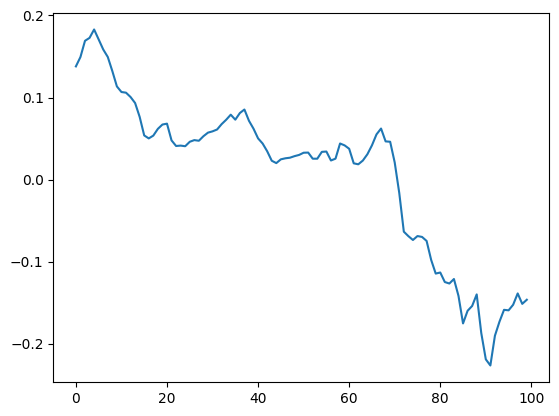

SharpRatio: 0.13229654563708837
11.070000000000011
200


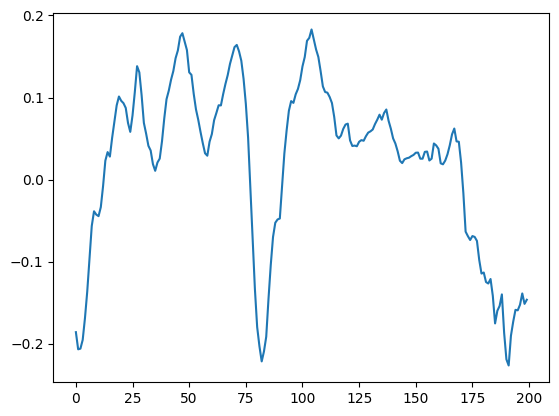

SharpRatio: 0.08814148693953014
14.304999999999978
300


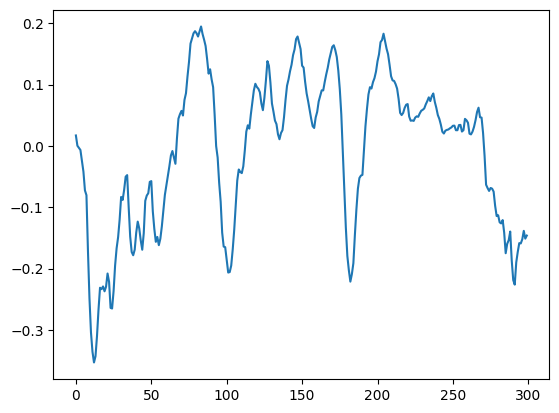

SharpRatio: 0.11483879263247611
34.43499999999995
400


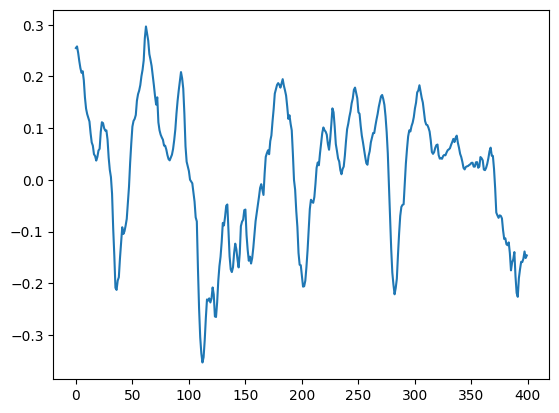

SharpRatio: 0.1148357876939556
45.64999999999991


In [12]:
from sklearn.linear_model import LinearRegression
import statsmodels
import statsmodels.api
import matplotlib.pyplot as plt
from sklearn import preprocessing
import cvxpy as cp

magic_num = 200
estimate_num = 150
predict_time = 30
r = 0.97474
order_num =1
window_size =1
MA_num = 1
MA_num2 =2


#comission = comission1
#amendment = first_val1

df_array = y_df.to_numpy()


for i in range(1,5):
  total_num = 100*i
  print(total_num)

  total_list = []
  y_list = []
  current_list = []
  result_list = []
  dms_list = []
  MA_hp_list = []
  return_list = []
  predict_flag2 = 0
  change_num = 0
  for j in range(magic_num-1,len(df_array)):
    X_list = []
    for k in range(magic_num):
      X_list.append(df_array[j-k])
    try:
      y_return = (df_array[j+1]-df_array[j])*1
    except:
      y_return = [0]
    #current_list.append(df_array[j-1])
    y_list.append(y_return)
    X_list2 = list(reversed(X_list))
    total_list.append(X_list2)
  #print(total_list)
  #print(y_list)
  total_list = np.array(total_list)
  y_list = np.array(y_list)
  #current_list = np.array(current_list)
  #print(total_list)
  #print(total_list.shape)
  #print(y_list.shape)
  for j in range(len(total_list)):
    if j <= len(total_list)-1-total_num:
      continue
    #print(j)
    X_array = np.array(total_list[j])
    y_array = y_list[j]
    result_list.append(y_array[0])
    X_df = pd.DataFrame(X_array)
    cycle, trend = sm.tsa.filters.hpfilter(X_df, 800)
    MA_hp = np.mean(trend[len(trend)-MA_num:])-np.mean(trend[len(trend)-MA_num2:])
    MA_hp_list.append(MA_hp)
    #print(MA_hp)


  #plt.plot(dms_list)
  #plt.show()
  MAdms_list=[]
  predict_flag2 = 0
  entry_flag = 0

  for j in range(len(MA_hp_list)):
    MA_hp = MA_hp_list[j]
    if MA_hp >0 :
      predict_flag = 1
    else:
      predict_flag = -1


    if predict_flag==predict_flag2:
      return_ = predict_flag*result_list[j]
      return_list.append(return_)
      predict_flag2 = predict_flag
    else:
      return_ = predict_flag*result_list[j] -0.1
      return_list.append(return_)
      predict_flag2 = predict_flag
    #return_ = predict_flag*result_list[j] -comission
    #print(return_)
    #return_list.append(return_)
  plt.plot(MA_hp_list)
  plt.show()

  R_sum = sum(return_list)
  SR = np.mean(np.array(return_list))/np.std(np.array(return_list))
  print("SharpRatio:",SR)
  print(R_sum)